# Instituto Superior de Engenharia do Porto (ISEP)
## Departamento de Engenharia Electrotécnica (DEE)
### Unidade Curricular: Sinais e Sistemas (SINSI)

---
# Resolução Detalhada de Exercícios Selecionados (TP04)



**Tópicos Abordados e objetivos:**
1. **Parte 1 - Correlação e Autocorrelação de Sinais:**
   - Medição de semelhança e coerência temporal (*Slide & Integrate* sem inversão).
   - Demonstração Interativa da Correlação em Tempo Contínuo.
   - **Exercício I (Extra):** Autocorrelação do Pulso Retangular e Relação com a Energia ($E_x$).
   - **Exercício II (Extra):** Deteção de Sinais Submersos em Ruído Forte (Aplicações em Radar e Comunicações).
2. **Parte 2 - Sistemas LIT e Operação de Convolução:**
   - A passagem de sinais por sistemas físicos e a necessidade da inversão temporal (*Flip & Slide*).
   - **Exercício 8:** Convolução em Tempo Contínuo.
   - Demonstração Interativa da Convolução Contínua.
   - **Exercício 11:** Convolução em Tempo Discreto (Métodos Analítico, Tabular e Matricial).
   - **Exercício 14:** Resposta ao Degrau Unitário ($s(t)$ e $s[n]$).


In [1]:
# Configuração e importação de módulos científicos em Python
import numpy as np
import scipy.signal as signal
import sympy as sp
import matplotlib.pyplot as plt

# Configuração estética dos gráficos
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.figsize'] = (10, 5)

print("Ambiente Python configurado com sucesso para a aula de Sinais e Sistemas!")


Ambiente Python configurado com sucesso para a aula de Sinais e Sistemas!


---
# PARTE 1: Correlação e Autocorrelação de Sinais

## 1. Fundamentos Teóricos: Medição de Semelhança entre Sinais

### 1.1 O que é a Correlação?
Antes de abordarmos a convolução em sistemas LIT, a operação mais natural e intuitiva entre dois sinais é a **Correlação**.
A correlação responde à pergunta fundamental de engenharia:  
> *"Quão semelhante é o sinal $x(t)$ com uma versão atrasada de $y(t)$ por um desfasamento temporal $\tau$?"*

Na parte 2 será abordada a convolução (que modela a resposta impulsional de sistemas físicos), muito semelhante, mas onde um dos sinais fica sujeito a uma **inversão temporal** (*time-reversal / flip*).

- **Correlação Cruzada (*Cross-correlation*):**
  $$r_{xy}(\tau) = \int_{-\infty}^{+\infty} x(t + \tau) y^*(t) dt = \int_{-\infty}^{+\infty} x(t) y^*(t - \tau) dt$$
  No domínio discreto:
  $$r_{xy}[m] = \sum_{n=-\infty}^{+\infty} x[n + m] y^*[n] = \sum_{n=-\infty}^{+\infty} x[n] y^*[n - m]$$

- **Autocorrelação (*Autocorrelation*):** É a correlação de um sinal consigo mesmo desfasado no tempo:
  - **Tempo Contínuo (Sinais de Energia):**
    $$R_{xx}(\tau) = \int_{-\infty}^{+\infty} x(t) x^*(t - \tau) dt$$
  - **Tempo Discreto (Sinais de Energia):**
    $$R_{xx}[m] = \sum_{n=-\infty}^{+\infty} x[n] x^*[n - m]$$

---

### 1.2 Propriedades Notáveis da Autocorrelação:
1. **Simetria / Paridade:** Para sinais reais ($x(t) \in \mathbb{R}$), a autocorrelação é uma função **par**:
   $$R_{xx}(-\tau) = R_{xx}(\tau) \qquad \text{e} \qquad R_{xx}[-m] = R_{xx}[m]$$
2. **Máximo Global na Origem (Energia Total):**
   $$R_{xx}(0) = \int_{-\infty}^{+\infty} |x(t)|^2 dt = E_x \qquad \text{e} \qquad |R_{xx}(\tau)| \le R_{xx}(0), \; \forall \tau$$
   *(O sinal atinge o grau máximo de semelhança consigo próprio para $\tau=0$).*
3. **Sinais Periódicos (Potência Média):**
   Para sinais periódicos com período $T_0$, $R_{xx}(\tau)$ é **estritamente periódico** com o mesmo período fundamental $T_0$, e o valor na origem é a potência média: $R_{xx}(0) = P_x$.
4. **Ligação com a Convolução:**
   $$R_{xx}(\tau) = x(\tau) * x^*(-\tau) \qquad \text{e} \qquad R_{xx}[m] = x[m] * x^*[-m]$$


---
## 2. Demonstração Interativa da Correlação Contínua (*Interactive Correlation Explorer*)

Para consolidar a intuição física da correlação (*Slide & Integrate*), explore o módulo interativo abaixo.
Arraste o **slider do desfasamento temporal $\tau$** e observe:
1. O sinal de referência fixo $x(t)$ (em azul) e o sinal deslocado $y(t - \tau)$ (em verde - **sem inversão**).
2. A área do produto pontual $x(t) \cdot y(t - \tau)$ sombreada em amarelo.
3. O traçado da função de correlação cruzada $r_{xy}(\tau)$ no painel inferior, com o pico máximo no ponto de maior alinhamento.


In [2]:
# Módulo Interativo de Correlação Contínua (ipywidgets + matplotlib)
import numpy as np
import matplotlib.pyplot as plt

def plot_correlacao_frame(tau_val=0.0):
    t_axis = np.linspace(-4.0, 4.0, 1500)
    dt = t_axis[1] - t_axis[0]
    
    # 1. Definição de dois pulsos para correlação cruzada
    x_t = np.maximum(0.0, 1.0 - np.abs(t_axis))
    y_t_shifted = np.where(np.abs(t_axis - tau_val) <= 0.75, 1.0, 0.0)
    
    # Produto pontual x(t) * y(t - tau)
    produto = x_t * y_t_shifted
    r_val = float(np.sum(produto) * dt)
    
    # 2. Curva completa de correlação
    tau_full = np.linspace(-3.5, 3.5, 400)
    r_full = []
    for tau_i in tau_full:
        y_i = np.where(np.abs(t_axis - tau_i) <= 0.75, 1.0, 0.0)
        r_full.append(float(np.sum(x_t * y_i) * dt))
    r_full = np.array(r_full)
    
    # 3. Construção dos Gráficos
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))
    
    # Subplot 1: Domínio temporal t
    ax1.plot(t_axis, x_t, 'b-', lw=2.5, label=r'Sinal Fixo $x(t)$ (Triangular)')
    ax1.plot(t_axis, y_t_shifted, 'g--', lw=2.0, label=f'Sinal Deslocado $y(t - ({tau_val:.2f}))$')
    ax1.fill_between(t_axis, produto, color='gold', alpha=0.55, 
                     label=f'Área de Coerência / Produto (Integral = {r_val:.3f})')
    ax1.axvline(tau_val, color='darkgreen', linestyle=':', label=f'Centro do atraso $\\tau = {tau_val:.2f}$')
    ax1.axhline(0, color='black', lw=0.8)
    ax1.set_xlim(-3.5, 3.5)
    ax1.set_ylim(-0.2, 1.3)
    ax1.set_xlabel('Tempo $t$ [s]')
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'Processo de Correlação: Alinhamento para $\\tau = {tau_val:.2f}$ s (Sem Inversão)', fontweight='bold')
    ax1.legend(loc='upper right', framealpha=0.9)
    
    # Subplot 2: Função de Correlação Cruzada r_xy(tau)
    ax2.plot(tau_full, r_full, 'm-', lw=2.5, label=r'Correlação Cruzada $r_{xy}(\tau)$')
    
    tau_past = tau_full[tau_full <= tau_val]
    if len(tau_past) > 0:
        r_past = r_full[:len(tau_past)]
        ax2.plot(tau_past, r_past, 'purple', lw=3.5, label='Trajetória percorrida')
        
    ax2.plot(tau_val, r_val, 'ro', markersize=9, label=f'$r_{{xy}}({tau_val:.2f}) = {r_val:.3f}$')
    ax2.axvline(tau_val, color='gray', linestyle=':')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_xlim(-3.5, 3.5)
    ax2.set_ylim(-0.1, max(r_full) * 1.25)
    ax2.set_xlabel(r'Desfasamento Temporal $\tau$ [s]')
    ax2.set_ylabel(r'$r_{xy}(\tau)$')
    ax2.set_title(r'Função de Correlação Resultante $r_{xy}(\tau) = \int_{-\infty}^{\infty} x(t) y(t-\tau) dt$', fontweight='bold')
    ax2.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Inicialização com ipywidgets
try:
    from ipywidgets import interact, FloatSlider
    import ipywidgets as widgets
    slider_corr = FloatSlider(min=-3.0, max=3.0, step=0.05, value=0.0, 
                              description='Atraso tau:', continuous_update=True,
                              layout=widgets.Layout(width='65%'))
    interact(plot_correlacao_frame, tau_val=slider_corr);
except ImportError:
    print("Módulo 'ipywidgets' não detetado. A renderizar visualização estática de referência:")
    plot_correlacao_frame(tau_val=0.0)


interactive(children=(FloatSlider(value=0.0, description='Atraso tau:', layout=Layout(width='65%'), max=3.0, m…

---
## 3. Exercícios Suplementares de Correlação e Autocorrelação

---

### Exercício I (Extra) - Autocorrelação do Pulso Retangular (Tempo Contínuo)

#### Enunciado:
Considere o pulso retangular centrado de duração $T$ e amplitude $A$:
$$x(t) = A \cdot \text{rect}\left(\frac{t}{T}\right) = \begin{cases} A, & -\frac{T}{2} \le t \le \frac{T}{2} \\[4pt] 0, & \text{caso contrário} \end{cases}$$

- **a)** Calcule analiticamente a função de autocorrelação $R_{xx}(\tau) = \int_{-\infty}^{+\infty} x(t) x(t - \tau) dt$.
- **b)** Esboce $R_{xx}(\tau)$ e comprove a relação de pico na origem $R_{xx}(0) = E_x$.

---

#### Resolução Analítica Passo a Passo:
1. **Suporte Temporal dos Pulsos:**
   - Pulso $x(t)$: $t \in [-T/2, \, T/2]$
   - Pulso deslocado $x(t - \tau)$: $t \in [\tau - T/2, \, \tau + T/2]$
2. **Integração por Casos de Desfasamento $\tau$:**
   - **Caso 1: $\tau < -T$ ou $\tau > T$** $\implies$ Sem sobreposição $\implies \mathbf{R_{xx}(\tau) = 0}$.
   - **Caso 2: $-T \le \tau < 0$** (Deslocamento à esquerda):
     $$R_{xx}(\tau) = \int_{-T/2}^{\tau + T/2} A^2 dt = A^2 \left[ (\tau + T/2) - (-T/2) \right] = \mathbf{A^2(T + \tau)}$$
   - **Caso 3: $0 \le \tau \le T$** (Deslocamento à direita):
     $$R_{xx}(\tau) = \int_{\tau - T/2}^{T/2} A^2 dt = A^2 \left[ T/2 - (\tau - T/2) \right] = \mathbf{A^2(T - \tau)}$$
3. **Expressão Analítica Compacta:**
   $$\mathbf{R_{xx}(\tau) = A^2 (T - |\tau|) \cdot \text{rect}\left(\frac{\tau}{2T}\right) = A^2 T \cdot \Lambda\left(\frac{\tau}{T}\right)}$$
   *(A autocorrelação de um pulso retangular é uma função **triangular** $\Lambda(\tau/T)$ com base $2T$).*
4. **Verificação da Energia:**
   $$R_{xx}(0) = A^2 T = \int_{-\infty}^{+\infty} |x(t)|^2 dt = E_x \quad \checkmark$$


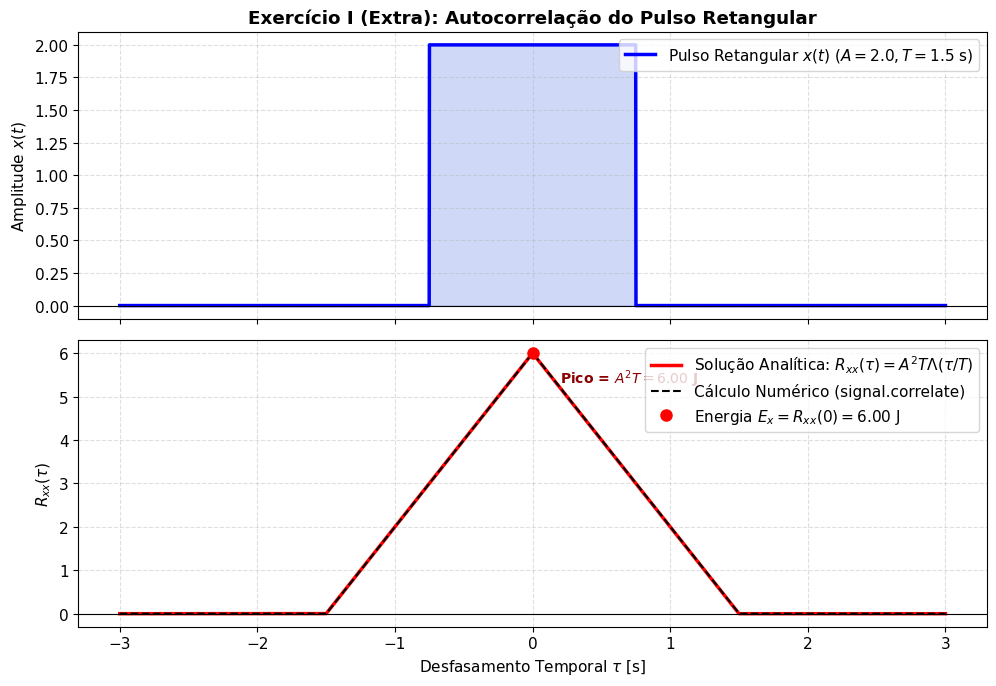

In [3]:
# Resolução Computacional do Exercício I (Extra)
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

A = 2.0      # Amplitude do pulso
T = 1.5      # Duração do pulso [s]

t_grid = np.linspace(-3.0, 3.0, 3000)
dt = t_grid[1] - t_grid[0]

# Sinal retangular x(t)
x_rect = np.where(np.abs(t_grid) <= T/2, A, 0.0)

# Solução Teórica: Pulso Triangular
tau_axis = np.linspace(-3.0, 3.0, 3000)
R_teorica = np.where(np.abs(tau_axis) <= T, (A**2) * (T - np.abs(tau_axis)), 0.0)

# Solução Numérica via correlate
R_numerica = signal.correlate(x_rect, x_rect, mode='same') * dt

# Visualização
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Gráfico de x(t)
ax1.plot(t_grid, x_rect, 'b-', lw=2.5, label=f'Pulso Retangular $x(t)$ ($A={A}, T={T}$ s)')
ax1.fill_between(t_grid, x_rect, color='royalblue', alpha=0.25)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel('Amplitude $x(t)$')
ax1.set_title('Exercício I (Extra): Autocorrelação do Pulso Retangular', fontweight='bold')
ax1.legend(loc='upper right')

# Gráfico de R_xx(tau)
ax2.plot(tau_axis, R_teorica, 'r-', lw=2.5, label=r'Solução Analítica: $R_{xx}(\tau) = A^2 T \Lambda(\tau/T)$')
ax2.plot(tau_axis, R_numerica, 'k--', lw=1.5, label='Cálculo Numérico (signal.correlate)')
ax2.axhline(0, color='black', lw=0.8)
ax2.plot(0, A**2 * T, 'ro', markersize=8, label=r'Energia $E_x = R_{xx}(0) = ' + f'{A**2 * T:.2f}$ J')
ax2.set_xlabel(r'Desfasamento Temporal $\tau$ [s]')
ax2.set_ylabel(r'$R_{xx}(\tau)$')
ax2.annotate(r'Pico = $A^2 T = ' + f'{A**2 * T:.2f}$ J', xy=(0, A**2 * T), xytext=(0.2, A**2 * T - 0.7),
             fontsize=10, fontweight='bold', color='darkred')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
### Exercício II (Extra) - Deteção de Sinais Submersos em Ruído Forte (Radar/Telecomunicações)

#### Enunciado:
Considere um sinal sinusoidal discreto corrompido por ruído branco gaussiano aditivo de média nula e variância $\sigma_w^2$:
$$x[n] = s[n] + w[n] = A \cos(\omega_0 n) + w[n]$$
com relação sinal-ruído negativa ($\text{SNR} = -6\text{ dB}$, ou seja, a potência do ruído é o dobro da potência do sinal).

- **a)** Deduza a expressão analítica da autocorrelação $R_{xx}[m]$ e explique porque é que o ruído é suprimido fora da origem ($m \ne 0$).
- **b)** Implemente uma simulação em Python demonstrando a recuperação do período fundamental $N_0 = 2\pi / \omega_0$.

---

#### Resolução Analítica:
Pela linearidade e como $s[n]$ e $w[n]$ são estatisticamente descorrelacionados ($R_{sw}[m] = 0$):
$$R_{xx}[m] = R_{ss}[m] + R_{ww}[m]$$

1. **Autocorrelação da Sinusoide:**
   $$R_{ss}[m] = \frac{A^2}{2} \cos(\omega_0 m)$$
   *(Preserva a periodicidade $N_0 = \frac{2\pi}{\omega_0}$ para qualquer valor de lag $m$)*.
2. **Autocorrelação do Ruído Branco:**
   $$R_{ww}[m] = \sigma_w^2 \delta[m]$$
   *(Concentra-se apenas na amostra central $m=0$ e anula-se para $m \ne 0$)*.

#### Conclusão para Engenharia:
Para $m \ne 0$:
$$R_{xx}[m] = \frac{A^2}{2} \cos(\omega_0 m)$$
A autocorrelação **elimina o ruído**, permitindo estimar frequências e sincronizar recetores mesmo com ruído severo.


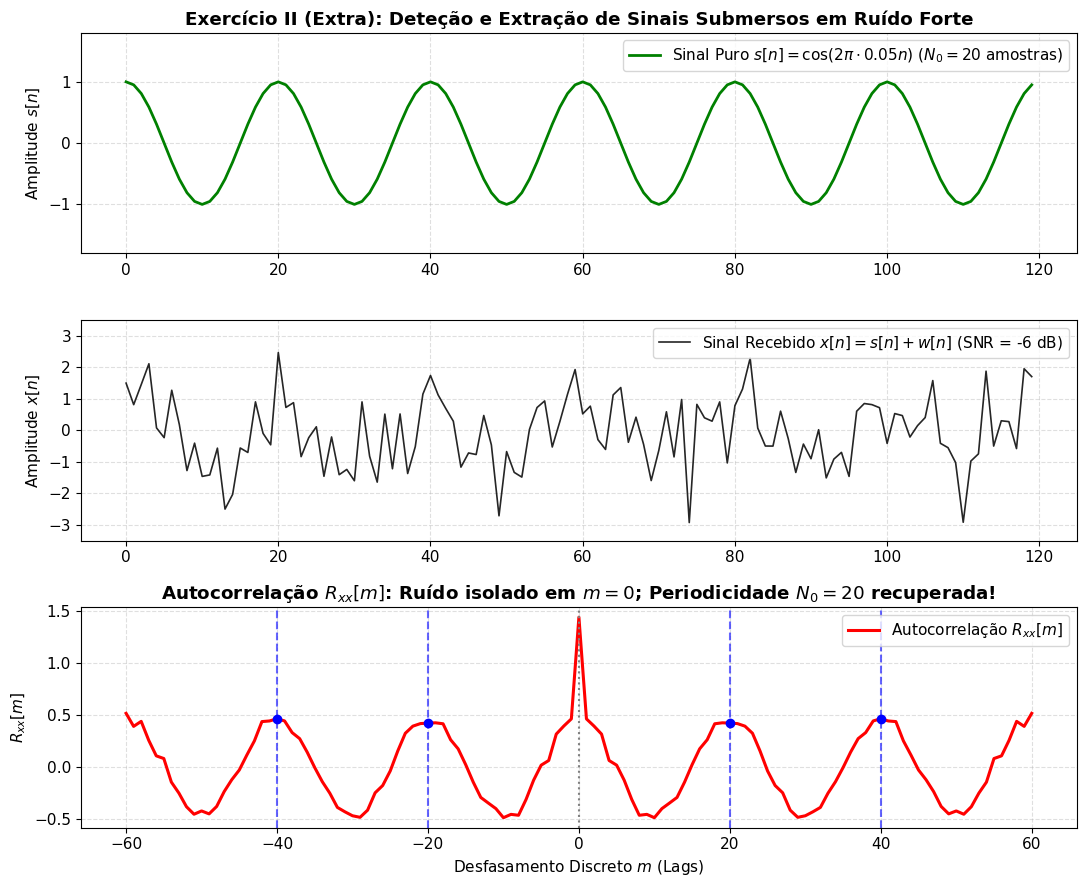

Período fundamental identificado via picos de autocorrelação: N0 = 20 amostras.


In [4]:
# Resolução Computacional do Exercício II (Extra)
import numpy as np
import matplotlib.pyplot as plt

# 1. Parâmetros de Simulação
np.random.seed(42)
N = 600
n = np.arange(N)
f0 = 0.05           # Frequência normalizada (Período N0 = 1/f0 = 20 amostras)
omega0 = 2 * np.pi * f0
A = 1.0             # Potência do sinal Ps = A^2/2 = 0.5

# 2. Sinal Útil e Ruído Branco (SNR = -6 dB => Pw = 1.0)
s_n = A * np.cos(omega0 * n)
w_n = np.random.normal(0, 1.0, N)
x_n = s_n + w_n

# 3. Autocorrelação Amostral
R_xx = np.correlate(x_n, x_n, mode='full') / N
lags = np.arange(-(N - 1), N)

mask_lags = (lags >= -60) & (lags <= 60)
lags_vis = lags[mask_lags]
R_vis = R_xx[mask_lags]

# 4. Visualização
fig, axs = plt.subplots(3, 1, figsize=(11, 9))

# Sinal Puro
axs[0].plot(n[:120], s_n[:120], 'g-', lw=2, label=r'Sinal Puro $s[n] = \cos(2\pi \cdot 0.05 n)$ ($N_0 = 20$ amostras)')
axs[0].set_title('Exercício II (Extra): Deteção e Extração de Sinais Submersos em Ruído Forte', fontweight='bold')
axs[0].set_ylabel('Amplitude $s[n]$')
axs[0].set_ylim(-1.8, 1.8)
axs[0].legend(loc='upper right')

# Sinal Ruidoso Recebido (SNR = -6 dB)
axs[1].plot(n[:120], x_n[:120], 'k-', lw=1.2, alpha=0.85, label='Sinal Recebido $x[n] = s[n] + w[n]$ (SNR = -6 dB)')
axs[1].set_ylabel('Amplitude $x[n]$')
axs[1].set_ylim(-3.5, 3.5)
axs[1].legend(loc='upper right')

# Autocorrelação R_xx[m]
axs[2].plot(lags_vis, R_vis, 'r-', lw=2.2, label=r'Autocorrelação $R_{xx}[m]$')
axs[2].axvline(0, color='gray', linestyle=':')
for peak_lag in [-40, -20, 20, 40]:
    axs[2].axvline(peak_lag, color='blue', linestyle='--', alpha=0.6)
    axs[2].plot(peak_lag, R_vis[lags_vis == peak_lag][0], 'bo')

axs[2].set_xlabel('Desfasamento Discreto $m$ (Lags)')
axs[2].set_ylabel(r'$R_{xx}[m]$')
axs[2].set_title(r'Autocorrelação $R_{xx}[m]$: Ruído isolado em $m=0$; Periodicidade $N_0=20$ recuperada!', fontweight='bold')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Período fundamental identificado via picos de autocorrelação: N0 = 20 amostras.")


---
# PARTE 2: Sistemas LIT, Convolução e Resposta ao Degrau

## 4. Fundamentos Teóricos: Sistemas LIT e a Operação de Convolução

### 4.1 Caracterização Completa pela Resposta Impulsional
Quando aplicamos um sinal a um sistema linear e invariante no tempo (LIT), cada ponto de entrada gera uma réplica da resposta impulsional $h(t)$ ponderada e atrasada.
A resposta total resulta da soma contínua (ou discreta) dessas contribuições, exigindo a **inversão temporal** (*time-reversal / flip*):

- **Tempo Contínuo (Integral de Convolução):**
  $$y(t) = x(t) * h(t) = \int_{-\infty}^{+\infty} x(\tau) h(t - \tau) d\tau$$
- **Tempo Discreto (Soma de Convolução):**
  $$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{+\infty} x[k] h[n - k]$$

---

### 4.2 Resumo da Técnica "Flip & Slide" na Convolução:
1. **Mudar de variável:** Escrever os sinais no domínio $\tau$ ($x(\tau)$ e $h(\tau)$).
2. **Inverter (Flip):** Obter $h(-\tau)$ (espelhamento em relação à origem $\tau = 0$).
3. **Deslocar (Slide):** Avançar por $t$, obtendo $h(t - \tau)$.
4. **Multiplicar e Integrar:** Calcular a área sob o produto $x(\tau) \cdot h(t - \tau)$.

---

### 4.3 Resposta ao Degrau Unitário ($s(t)$ e $s[n]$):
- **Contínuo:** $s(t) = \int_{-\infty}^{t} h(\tau) d\tau \iff h(t) = \frac{ds(t)}{dt}$
- **Discreto:** $s[n] = \sum_{k=-\infty}^{n} h[k] \iff h[n] = s[n] - s[n-1]$


---
## 5. Exercício 8 - Convolução em Tempo Contínuo

### Enunciado:
Considere os sinais contínuos:
$$h(t) = 1, \quad \text{para } -1 \le t \le 1 \quad (0 \text{ nos restantes instantes})$$
$$x(t) = \cos(\pi t), \quad \text{para } -1 \le t \le 1 \quad (0 \text{ nos restantes instantes})$$

Calcule analiticamente e esboce o sinal de saída $y_1(t) = x(t) * h(t)$.

---

### Resolução Analítica Passo a Passo:

#### 1. Suporte e Simetria:
- Suporte do sinal de entrada $x(t)$: $t \in [-1, \, 1]$.
- Suporte da resposta impulsional $h(t)$: $t \in [-1, \, 1]$.
- Suporte total da convolução $y_1(t)$: $[t_{x,\text{mín}} + t_{h,\text{mín}}, \, t_{x,\text{máx}} + t_{h,\text{máx}}] = [-1 + (-1), \, 1 + 1] = [-2, \, 2]$.
- Como $x(t)$ e $h(t)$ são funções **pares**, a convolução $y_1(t)$ é garantidamente uma função **par** ($y_1(-t) = y_1(t)$).

---

#### 2. Definição da Variável Muda de Integração $\tau$ e o Mecanismo *Flip & Slide*:
Na integral de convolução $y_1(t) = \int_{-\infty}^{+\infty} x(\tau) h(t - \tau) d\tau$:
1. **Sinal fixo $x(\tau)$:** Vale $\cos(\pi \tau)$ para $\tau \in [-1, \, 1]$ e zero fora desse intervalo.
2. **Sinal invertido e deslocado $h(t - \tau)$:**
   $$h(\tau) = 1 \text{ para } -1 \le \tau \le 1 \implies h(t - \tau) = 1 \text{ para } -1 \le t - \tau \le 1$$
   Subtraindo $t$ e multiplicando por $-1$ (invertendo o sentido das desigualdades):
   $$-1 - t \le -\tau \le 1 - t \iff \mathbf{t - 1 \le \tau \le t + 1}$$
   *Interpretação Geométrica:* O pulso $h(t - \tau)$ é uma janela retangular de amplitude $1$ e largura fixa igual a $2$, cujo **bordo traseiro (início)** está em $\tau = t - 1$ e cujo **bordo dianteiro (fim)** está em $\tau = t + 1$. À medida que o instante $t$ varia, a janela desliza da esquerda para a direita ao longo do eixo $\tau$.

3. **Regra Fundamental dos Limites de Integração:**
   O integrando $x(\tau) \cdot h(t - \tau)$ só é não-nulo na **interseção dos suportes** de ambos os sinais:
   $$I_{\text{int}}(t) = \text{Suporte}\{x(\tau)\} \cap \text{Suporte}\{h(t - \tau)\} = [-1, \, 1] \cap [t - 1, \, t + 1]$$
   Portanto, os limites efetivos de integração são analiticamente:
   $$\tau_{\text{inferior}} = \max(-1, \, t - 1) \qquad \text{e} \qquad \tau_{\text{superior}} = \min(1, \, t + 1)$$

---

#### 3. Análise Detalhada dos Intervalos e Limites de Integração (Casos 1, 2 e 3):

* **Caso 1: Sem Sobreposição ($t < -2$ ou $t > 2$)**
  - Para $t < -2 \implies t + 1 < -1$: o bordo dianteiro da janela $h(t-\tau)$ ainda não alcançou o início do sinal $x(\tau)$.
  - Para $t > 2 \implies t - 1 > 1$: o bordo traseiro da janela já ultrapassou o fim do sinal $x(\tau)$.
  - Em ambos os casos, a interseção é vazia $\implies \mathbf{y_1(t) = 0}$.

* **Caso 2: Entrada do Pulso / Sobreposição Parcial à Esquerda ($-2 \le t < 0$)**
  - **Origem dos Limites de Integração (Porquê $\tau \in [-1, \, t+1]$?):**
    - O bordo dianteiro da janela já entrou em $x(\tau)$ (pois $t + 1 \ge -1 \iff t \ge -2$), mas ainda não o atravessou completamente (pois $t + 1 < 1 \iff t < 0$).
    - O bordo traseiro da janela ainda está à esquerda de $x(\tau)$ (pois $t - 1 < -1 \iff t < 0$).
    - Logo:
      $$\tau_{\text{inferior}} = \max(-1, \, t - 1) = \mathbf{-1} \quad (\text{o sinal } x(\tau) \text{ só começa em } -1)$$
      $$\tau_{\text{superior}} = \min(1, \, t + 1) = \mathbf{t + 1} \quad (\text{a janela } h(t-\tau) \text{ termina em } t + 1)$$
  - **Cálculo da Integral:**
    $$y_1(t) = \int_{-1}^{t+1} \cos(\pi \tau) d\tau = \left[ \frac{\sin(\pi \tau)}{\pi} \right]_{-1}^{t+1} = \frac{\sin(\pi(t+1)) - \sin(-\pi)}{\pi}$$
    Como $\sin(-\pi) = 0$ e $\sin(\pi t + \pi) = -\sin(\pi t)$, obtemos:
    $$\mathbf{y_1(t) = -\frac{\sin(\pi t)}{\pi}}$$

* **Caso 3: Saída do Pulso / Sobreposição Parcial à Direita ($0 \le t \le 2$)**
  - **Origem dos Limites de Integração (Porquê $\tau \in [t-1, \, 1]$?):**
    - O bordo dianteiro da janela já ultrapassou o fim de $x(\tau)$ (pois $t + 1 \ge 1 \iff t \ge 0$).
    - O bordo traseiro da janela já penetrou no domínio de $x(\tau)$ (pois $t - 1 \ge -1 \iff t \ge 0$), mas ainda não saiu (pois $t - 1 \le 1 \iff t \le 2$).
    - Logo:
      $$\tau_{\text{inferior}} = \max(-1, \, t - 1) = \mathbf{t - 1} \quad (\text{a janela } h(t-\tau) \text{ só existe a partir de } t - 1)$$
      $$\tau_{\text{superior}} = \min(1, \, t + 1) = \mathbf{1} \quad (\text{o sinal } x(\tau) \text{ termina em } 1)$$
  - **Cálculo da Integral:**
    $$y_1(t) = \int_{t-1}^{1} \cos(\pi \tau) d\tau = \left[ \frac{\sin(\pi \tau)}{\pi} \right]_{t-1}^{1} = \frac{\sin(\pi) - \sin(\pi(t-1))}{\pi}$$
    Como $\sin(\pi) = 0$ e $\sin(\pi(t-1)) = \sin(\pi t - \pi) = -\sin(\pi t)$, obtemos:
    $$\mathbf{y_1(t) = \frac{0 - (-\sin(\pi t))}{\pi} = \frac{\sin(\pi t)}{\pi}}$$

---

#### 4. Resumo Síntese e Expressão Analítica Final:

| Intervalo de $t$ | Bordo Traseiro $\tau = t-1$ | Bordo Dianteiro $\tau = t+1$ | Intervalo Efetivo de Integração em $\tau$ | Expressão de $y_1(t)$ |
| :--- | :--- | :--- | :--- | :--- |
| $t < -2$ | Fora ($\tau < -3$) | Fora ($\tau < -1$) | Sem sobreposição | $0$ |
| $-2 \le t < 0$ | Fora ($t-1 < -1$) | Dentro ($-1 \le t+1 < 1$) | $\tau \in [-1, \, t+1]$ | $-\dfrac{\sin(\pi t)}{\pi}$ |
| $0 \le t \le 2$ | Dentro ($-1 \le t-1 \le 1$) | Fora ($t+1 > 1$) | $\tau \in [t-1, \, 1]$ | $\dfrac{\sin(\pi t)}{\pi}$ |
| $t > 2$ | Fora ($t-1 > 1$) | Fora ($t+1 > 3$) | Sem sobreposição | $0$ |

$$\mathbf{y_1(t) = \begin{cases} 
0, & t < -2 \\[6pt]
-\dfrac{\sin(\pi t)}{\pi}, & -2 \le t < 0 \\[6pt]
\dfrac{\sin(\pi t)}{\pi}, & 0 \le t \le 2 \\[6pt]
0, & t > 2
\end{cases} \quad = \quad \text{sgn}(t) \cdot \frac{\sin(\pi t)}{\pi} \cdot \text{rect}\left(\frac{t}{4}\right)}$$

> **Verificação de Continuidade em $t=0$:**  
> $\lim_{t \to 0^-} y_1(t) = -\frac{\sin(0)}{\pi} = 0$, $\lim_{t \to 0^+} y_1(t) = \frac{\sin(0)}{\pi} = 0$, e $y_1(0) = \int_{-1}^1 \cos(\pi \tau) d\tau = \left[\frac{\sin(\pi\tau)}{\pi}\right]_{-1}^1 = 0$. A transição é perfeitamente suave e contínua!


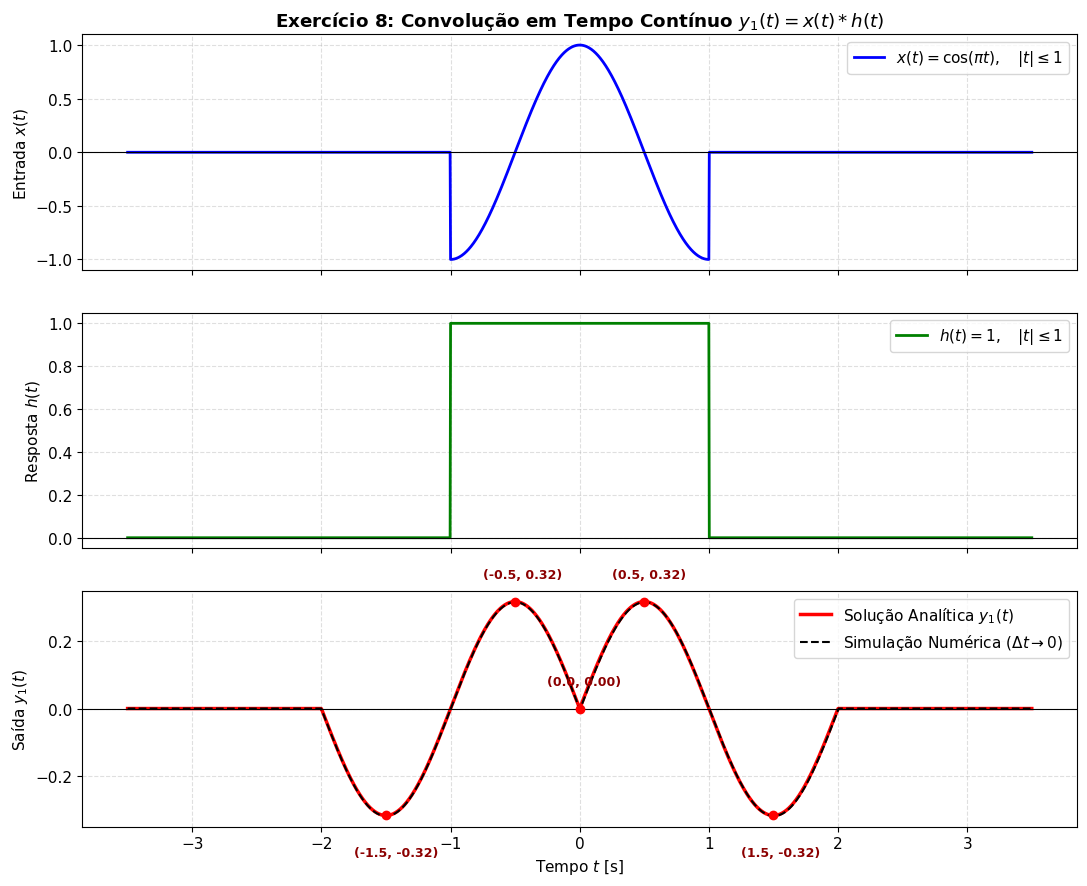

In [5]:
# Resolução Computacional do Exercício 8
import numpy as np
import matplotlib.pyplot as plt

t_cont = np.linspace(-3.5, 3.5, 2000)
dt = t_cont[1] - t_cont[0]

x_t = np.where(np.abs(t_cont) <= 1.0, np.cos(np.pi * t_cont), 0.0)
h_t = np.where(np.abs(t_cont) <= 1.0, 1.0, 0.0)

def y_analitica(t):
    y = np.zeros_like(t, dtype=float)
    idx1 = (t >= -2.0) & (t < 0.0)
    y[idx1] = -np.sin(np.pi * t[idx1]) / np.pi
    idx2 = (t >= 0.0) & (t <= 2.0)
    y[idx2] = np.sin(np.pi * t[idx2]) / np.pi
    return y

y_teorico = y_analitica(t_cont)
y_numerico = np.convolve(x_t, h_t, mode='same') * dt

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axs[0].plot(t_cont, x_t, 'b-', lw=2, label=r'$x(t) = \cos(\pi t), \quad |t| \leq 1$')
axs[0].axhline(0, color='black', lw=0.8)
axs[0].set_ylabel('Entrada $x(t)$')
axs[0].set_title('Exercício 8: Convolução em Tempo Contínuo $y_1(t) = x(t) * h(t)$', fontweight='bold')
axs[0].legend(loc='upper right')

axs[1].plot(t_cont, h_t, 'g-', lw=2, label=r'$h(t) = 1, \quad |t| \leq 1$')
axs[1].axhline(0, color='black', lw=0.8)
axs[1].set_ylabel('Resposta $h(t)$')
axs[1].legend(loc='upper right')

axs[2].plot(t_cont, y_teorico, 'r-', lw=2.5, label='Solução Analítica $y_1(t)$')
axs[2].plot(t_cont, y_numerico, 'k--', lw=1.5, label=r'Simulação Numérica ($\Delta t \to 0$)')
axs[2].axhline(0, color='black', lw=0.8)
axs[2].set_xlabel('Tempo $t$ [s]')
axs[2].set_ylabel('Saída $y_1(t)$')

pontos_t = [-1.5, -0.5, 0.0, 0.5, 1.5]
for pt in pontos_t:
    val = y_analitica(np.array([pt]))[0]
    axs[2].plot(pt, val, 'ro')
    offset_y = 0.07 if val >= 0 else -0.12
    axs[2].annotate(f'({pt:.1f}, {val:.2f})', xy=(pt, val), xytext=(pt - 0.25, val + offset_y),
                    fontsize=9, weight='bold', color='darkred')

axs[2].legend(loc='upper right')
plt.tight_layout()
plt.show()


In [6]:
# Validação Simbólica com SymPy
t_sym, tau_sym = sp.symbols('t tau', real=True)
integrando = sp.cos(sp.pi * tau_sym) * 1

res_sympy_caso3 = sp.integrate(integrando, (tau_sym, t_sym - 1, 1))
res_sympy_caso2 = sp.integrate(integrando, (tau_sym, -1, t_sym + 1))

print("Validação Simbólica (SymPy):")
print(f"Para 0 <= t <= 2: y_1(t) = {sp.simplify(res_sympy_caso3)}")
print(f"Para -2 <= t < 0: y_1(t) = {sp.simplify(res_sympy_caso2)}")


Validação Simbólica (SymPy):
Para 0 <= t <= 2: y_1(t) = sin(pi*t)/pi
Para -2 <= t < 0: y_1(t) = sin(pi*(t + 1))/pi


---
## 6. Demonstração Interativa da Convolução Contínua (*Interactive Convolution Explorer*)

Compare agora com o módulo interativo de correlação da Secção 2: observe como o sinal $h(t - \tau)$ está **invertido** antes de ser deslocado (*Flip and Slide*).


In [7]:
# Módulo Interativo de Convolução Contínua (Totalmente Autónomo)
import numpy as np
import matplotlib.pyplot as plt

def plot_convolucao_frame(t_val=-0.5):
    tau_grid = np.linspace(-4, 4, 1500)
    d_tau = tau_grid[1] - tau_grid[0]
    
    # 1. Sinais no domínio tau (Flip & Slide)
    x_tau = np.where(np.abs(tau_grid) <= 1.0, np.cos(np.pi * tau_grid), 0.0)
    h_t_minus_tau = np.where(np.abs(t_val - tau_grid) <= 1.0, 1.0, 0.0)
    
    # Produto pontual x(tau) * h(t - tau) e integral numérico no instante t_val
    produto = x_tau * h_t_minus_tau
    y_val = float(np.sum(produto) * d_tau)
    
    # 2. Curva teórica de saída y1(t)
    t_full = np.linspace(-3.5, 3.5, 800)
    y_full = np.zeros_like(t_full)
    idx1 = (t_full >= -2.0) & (t_full < 0.0)
    y_full[idx1] = -np.sin(np.pi * t_full[idx1]) / np.pi
    idx2 = (t_full >= 0.0) & (t_full <= 2.0)
    y_full[idx2] = np.sin(np.pi * t_full[idx2]) / np.pi
    
    # 3. Construção dos Gráficos
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))
    
    # Subplot 1: Domínio tau (Flip & Slide)
    ax1.plot(tau_grid, x_tau, 'b-', lw=2, label=r'$x(\tau) = \cos(\pi \tau)$')
    ax1.plot(tau_grid, h_t_minus_tau, 'g--', lw=2, label=f'h({t_val:.2f} - tau)')
    ax1.fill_between(tau_grid, produto, color='gold', alpha=0.55, 
                     label=f'Área do Produto = {y_val:.3f}')
    ax1.axvline(t_val, color='darkgreen', linestyle=':', label=f'Centro t = {t_val:.2f}')
    ax1.axhline(0, color='black', lw=0.8)
    ax1.set_xlim(-3.5, 3.5)
    ax1.set_ylim(-1.2, 1.4)
    ax1.set_xlabel(r'Variável de Integração $\tau$ [s]')
    ax1.set_ylabel(r'Amplitude em $\tau$')
    ax1.set_title(f'Processo de Convolução no domínio $\\tau$ para $t = {t_val:.2f}$ s (Com Inversão)', fontweight='bold')
    ax1.legend(loc='upper right', framealpha=0.9)
    
    # Subplot 2: Saída y1(t) construída
    ax2.plot(t_full, y_full, 'r-', lw=2, label=r'Saída Teórica $y_1(t)$')
    
    t_past = t_full[t_full <= t_val]
    if len(t_past) > 0:
        y_past = y_full[:len(t_past)]
        ax2.plot(t_past, y_past, 'darkred', lw=3.5, label='Trajetória percorrida')
    
    ax2.plot(t_val, y_val, 'ro', markersize=9, label=f'$y_1({t_val:.2f}) = {y_val:.3f}$')
    ax2.axvline(t_val, color='gray', linestyle=':')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_xlim(-3.5, 3.5)
    ax2.set_ylim(-0.45, 0.45)
    ax2.set_xlabel('Tempo $t$ [s]')
    ax2.set_ylabel(r'Saída $y_1(t)$')
    ax2.set_title('Sinal de Saída Resultante $y_1(t) = x(t) * h(t)$', fontweight='bold')
    ax2.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Inicialização com ipywidgets
try:
    from ipywidgets import interact, FloatSlider
    import ipywidgets as widgets
    slider = FloatSlider(min=-3.0, max=3.0, step=0.05, value=0.5, 
                         description='Instante t:', continuous_update=True,
                         layout=widgets.Layout(width='65%'))
    interact(plot_convolucao_frame, t_val=slider);
except ImportError:
    print("Módulo 'ipywidgets' não detetado. A renderizar visualização estática:")
    plot_convolucao_frame(t_val=0.5)


interactive(children=(FloatSlider(value=0.5, description='Instante t:', layout=Layout(width='65%'), max=3.0, m…

---
## 7. Exercício 11 - Convolução em Tempo Discreto

### Enunciado:
Considere os sinais discretos que representam a resposta impulsional e a entrada de um sistema LIT discreto:
$$h[n] = 1, \quad \text{para } 0 \le n \le 3 \quad (0 \text{ nos restantes instantes})$$
$$x[n] = \{2, 1\}, \quad \text{para } n \in \{0, 1\} \quad (0 \text{ nos restantes instantes})$$

Calcule analiticamente e esboce o sinal de saída $y[n] = x[n] * h[n]$.

---

### Resolução Analítica por Três Métodos Complementares:

#### Método 1: Respostas Impulsionais Atrasadas Ponderadas
$$x[n] = 2\delta[n] + 1\delta[n-1] \implies y[n] = 2h[n] + 1h[n-1]$$
- $n=0$: $y[0] = 2(1) + 1(0) = \mathbf{2}$
- $n=1$: $y[1] = 2(1) + 1(1) = \mathbf{3}$
- $n=2$: $y[2] = 2(1) + 1(1) = \mathbf{3}$
- $n=3$: $y[3] = 2(1) + 1(1) = \mathbf{3}$
- $n=4$: $y[4] = 2(0) + 1(1) = \mathbf{1}$

$$\mathbf{y[n] = \{2, 3, 3, 3, 1\}, \quad n = 0, 1, 2, 3, 4}$$

---

#### Método 2: Método Tabular

| $\times$ | $h[0]=1$ | $h[1]=1$ | $h[2]=1$ | $h[3]=1$ |
|:---:|:---:|:---:|:---:|:---:|
| **$x[0] = 2$** | **2** | **2** | **2** | **2** |
| **$x[1] = 1$** | (atraso) | **1** | **1** | **1** | **1** |
| **Soma $y[n]$** | **$y[0]=2$** | **$y[1]=3$** | **$y[2]=3$** | **$y[3]=3$** | **$y[4]=1$** |

---

#### Método 3: Formulação Matricial (Toeplitz)
$$\begin{bmatrix} y[0] \\ y[1] \\ y[2] \\ y[3] \\ y[4] \end{bmatrix} = \begin{bmatrix} 
1 & 0 \\ 
1 & 1 \\ 
1 & 1 \\ 
1 & 1 \\ 
0 & 1 
\end{bmatrix} \begin{bmatrix} 2 \\ 1 \end{bmatrix} = \begin{bmatrix} 2 \\ 3 \\ 3 \\ 3 \\ 1 \end{bmatrix}$$


Resultados Numéricos da Convolução Discreta:
Instantes n: [0 1 2 3 4]
Valores de y[n]: [2 3 3 3 1]


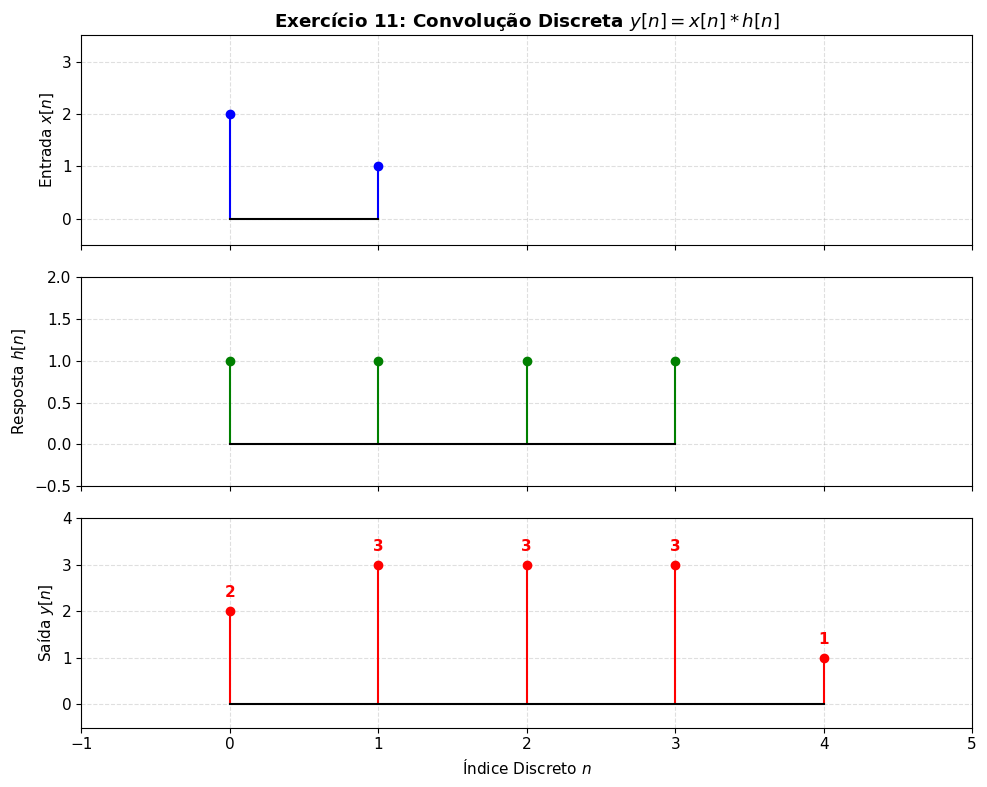

In [8]:
# Resolução Computacional do Exercício 11
import numpy as np
import matplotlib.pyplot as plt

n_x = np.array([0, 1])
x = np.array([2, 1])

n_h = np.array([0, 1, 2, 3])
h = np.array([1, 1, 1, 1])

y = np.convolve(x, h)
n_y = np.arange(n_x[0] + n_h[0], n_x[-1] + n_h[-1] + 1)

print("Resultados Numéricos da Convolução Discreta:")
print(f"Instantes n: {n_y}")
print(f"Valores de y[n]: {y}")

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt='k-')
axs[0].set_title('Exercício 11: Convolução Discreta $y[n] = x[n] * h[n]$', fontweight='bold')
axs[0].set_ylabel('Entrada $x[n]$')
axs[0].set_ylim(-0.5, 3.5)

axs[1].stem(n_h, h, linefmt='g-', markerfmt='go', basefmt='k-')
axs[1].set_ylabel('Resposta $h[n]$')
axs[1].set_ylim(-0.5, 2.0)

axs[2].stem(n_y, y, linefmt='r-', markerfmt='ro', basefmt='k-')
axs[2].set_xlabel('Índice Discreto $n$')
axs[2].set_ylabel('Saída $y[n]$')
axs[2].set_ylim(-0.5, 4.0)
axs[2].set_xticks(np.arange(-1, 6))

for i, txt in enumerate(y):
    axs[2].annotate(f'{txt}', (n_y[i], txt + 0.3), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()


In [9]:
# Visualização Interativa Discreta
import numpy as np
import matplotlib.pyplot as plt

def plot_convolucao_discreta_frame(n_deslocamento=2):
    k_range = np.arange(-2, 6)
    x_k = np.array([2 if k==0 else 1 if k==1 else 0 for k in k_range])
    h_n_minus_k = np.array([1 if 0 <= (n_deslocamento - k) <= 3 else 0 for k in k_range])
    
    prod_k = x_k * h_n_minus_k
    y_actual = int(np.sum(prod_k))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5))
    
    ax1.stem(k_range - 0.1, x_k, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$x[k]$')
    ax1.stem(k_range + 0.1, h_n_minus_k, linefmt='g--', markerfmt='gs', basefmt='k-', label=f'h[{n_deslocamento} - k]')
    ax1.bar(k_range, prod_k, color='gold', alpha=0.5, width=0.4, label=f'Produto x[k]h[{n_deslocamento}-k] (Soma = {y_actual})')
    ax1.set_title(f'Multiplicação e Acumulação no domínio $k$ para $n = {n_deslocamento}$', fontweight='bold')
    ax1.set_xlabel('Índice $k$')
    ax1.set_ylabel('Amplitude')
    ax1.set_ylim(-0.5, 3.2)
    ax1.legend(loc='upper right')
    
    n_full = np.arange(0, 5)
    y_full = np.array([2, 3, 3, 3, 1])
    ax2.stem(n_full, y_full, linefmt='lightgray', markerfmt='o', basefmt='k-', label='$y[n]$ completo')
    if 0 <= n_deslocamento <= 4:
        ax2.stem([n_deslocamento], [y_actual], linefmt='r-', markerfmt='ro', basefmt='k-', label=f'$y[{n_deslocamento}] = {y_actual}$')
    
    ax2.set_title('Saída Discreta $y[n]$ resultante', fontweight='bold')
    ax2.set_xlabel('Índice $n$')
    ax2.set_ylabel('Amplitude')
    ax2.set_xlim(-1.5, 5.5)
    ax2.set_ylim(-0.5, 4.0)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

try:
    from ipywidgets import IntSlider, interact
    slider_discreto = IntSlider(min=-1, max=5, step=1, value=1, description='Índice n:')
    interact(plot_convolucao_discreta_frame, n_deslocamento=slider_discreto);
except ImportError:
    print("Módulo 'ipywidgets' não detetado. A renderizar visualização estática:")
    plot_convolucao_discreta_frame(n_deslocamento=1)


interactive(children=(IntSlider(value=1, description='Índice n:', max=5, min=-1), Output()), _dom_classes=('wi…

---
## 8. Exercício 14 - Resposta ao Degrau em Sistemas LIT

### Enunciado:
Calcule a resposta ao degrau unitário $s(t)$ ou $s[n]$ para os sistemas LIT representados pelas seguintes respostas impulsionais:
- **a)** $h(t) = e^{-|t|}$ (Tempo Contínuo)
- **d)** $h[n] = \delta[n] - \delta[n-2]$ (Tempo Discreto)

---

### Resolução Analítica — Alínea a): $h(t) = e^{-|t|}$
$$s(t) = \int_{-\infty}^{t} e^{-|\tau|} d\tau$$
- Para $t < 0$: $s(t) = \int_{-\infty}^{t} e^{\tau} d\tau = \mathbf{e^t}$
- Para $t \ge 0$: $s(t) = \int_{-\infty}^{0} e^{\tau} d\tau + \int_{0}^{t} e^{-\tau} d\tau = 1 + (1 - e^{-t}) = \mathbf{2 - e^{-t}}$

$$\mathbf{s(t) = e^t u(-t) + (2 - e^{-t}) u(t)}$$

---

### Resolução Analítica — Alínea d): $h[n] = \delta[n] - \delta[n-2]$
$$s[n] = u[n] - u[n-2] = \mathbf{\delta[n] + \delta[n-1]} = \begin{cases} 1, & n = 0, 1 \\[4pt] 0, & \text{caso contrário} \end{cases}$$


In [ ]:
# Simulação do Exercício 14a
import numpy as np
import matplotlib.pyplot as plt

t_ex14 = np.linspace(-4, 4, 1000)
h_ex14 = np.exp(-np.abs(t_ex14))
s_analitica = np.where(t_ex14 < 0, np.exp(t_ex14), 2.0 - np.exp(-t_ex14))

dt_14 = t_ex14[1] - t_ex14[0]
s_numerica = np.cumsum(h_ex14) * dt_14

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(t_ex14, h_ex14, 'b-', lw=2, label=r'$h(t) = e^{-|t|}$')
ax1.fill_between(t_ex14, h_ex14, color='lightblue', alpha=0.3)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel(r'$h(t)$')
ax1.set_title('Exercício 14a: Resposta Impulsional $h(t) = e^{-|t|}$ (Sistema Não Causal)', fontweight='bold')
ax1.legend(loc='upper right')

ax2.plot(t_ex14, s_analitica, 'r-', lw=2.5, label=r'Solução Analítica $s(t) = e^t u(-t) + (2 - e^{-t})u(t)$')
ax2.plot(t_ex14, s_numerica, 'k--', lw=1.2, label='Integração Numérica')
ax2.axhline(1.0, color='gray', linestyle=':', label='Transição em $t=0$ ($s(0)=1$)')
ax2.axhline(2.0, color='darkgreen', linestyle='--', label=r'Assíntota $s(\infty)=2$')
ax2.axhline(0, color='black', lw=0.8)
ax2.plot(0, 1.0, 'ro', markersize=7)
ax2.set_xlabel('Tempo $t$ [s]')
ax2.set_ylabel(r'Resposta ao Degrau $s(t)$')
ax2.set_title('Resposta ao Degrau Unitário $s(t)$', fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
# Simulação do Exercício 14d
import numpy as np
import matplotlib.pyplot as plt

n_ex14d = np.arange(-3, 6)
h_14d = np.array([1 if n==0 else -1 if n==2 else 0 for n in n_ex14d])
s_14d = np.array([1 if n in [0, 1] else 0 for n in n_ex14d])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.stem(n_ex14d, h_14d, linefmt='g-', markerfmt='go', basefmt='k-')
ax1.set_ylabel(r'$h[n]$')
ax1.set_title('Exercício 14d: Resposta Impulsional $h[n] = \delta[n] - \delta[n-2]$', fontweight='bold')
ax1.set_ylim(-1.5, 1.5)

ax2.stem(n_ex14d, s_14d, linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.set_xlabel('Índice Discreto $n$')
ax2.set_ylabel(r'$s[n]$')
ax2.set_title(r'Resposta ao Degrau $s[n] = u[n] - u[n-2] = \delta[n] + \delta[n-1]$', fontweight='bold')
ax2.set_ylim(-0.5, 1.8)
ax2.set_xticks(n_ex14d)

for n, val in zip(n_ex14d, s_14d):
    ax2.annotate(f'{val}', (n, val + 0.15), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()


---
## 9. Síntese e Conclusões da Aula Prática

### Quadro Comparativo Essencial para Engenharia:

| Conceito | Operação | Inversão Temporal (*Flip*)? | Aplicação Principal |
| :--- | :---: | :---: | :--- |
| **Correlação** | $x(t) * x^*(-t)$ | **Não** | Medição de semelhança, radar, alinhamento, deteção de sinais em ruído. |
| **Convolução** | $x(t) * h(t)$ | **Sim** | Modelação da saída de sistemas físicos LIT dada a resposta impulsional $h(t)$. |
| **Resposta ao Degrau** | $\int_{-\infty}^t h(\tau) d\tau$ | — | Caracterização da dinâmica transitória e ganho estático em controlo e telecomunicações. |

---
*Bom estudo a todos! Pratiquem os exercícios da folha e utilizem os módulos interativos deste notebook para ganhar intuição geométrica.*
